### CFO Consistency Evaluation

This notebook explores the consistency of CFO -- carrier frequency offses -- throughout the frames within a day and throughout multiple days. Here, we work with both WiSig and MobRFFI datasets. 

In [16]:
%reload_ext autoreload
%autoreload 2

import os
import numpy as np
import utils
import cfo_utils
import matplotlib.pyplot as plt
from dataset_api import DatasetAPI

DATASET_NAME =           DatasetAPI.DATASET_V2V4
ROOT_DIRECTORY =         '/home/smazokha2016/Desktop'
MATLAB_SRC_DIRECTORY =   '/home/smazokha2016/Desktop/mobintel-rffi/fingerprinting'
MATLAB_SESSION_ID =      'fp_workflow'

dataset_api = DatasetAPI(root_dir=ROOT_DIRECTORY, matlab_src_dir=MATLAB_SRC_DIRECTORY, matlab_session_id=MATLAB_SESSION_ID, aug_on=False)

In [13]:
# Function to plot CFO values
def plot_dataset_cfo(dataset_cfo, node_ids, day_start_idx, epoch_frames, epoch_skip, figtitle):
    utils.apply_ieee_style()

    epoch_labels = []
    epoch_ticks = []

    for d in range(len(day_start_idx)-1):
        epoch_labels += [f'E {int((e_idx-day_start_idx[d])/epoch_frames+1)}' for e_idx in range(day_start_idx[d], day_start_idx[d+1], epoch_frames * epoch_skip)]
        epoch_ticks += [e_idx for e_idx in range(day_start_idx[d], day_start_idx[d+1], epoch_frames * epoch_skip)]

    plt.figure(figsize=(10, 6), dpi=120)
    for device_i in range(dataset_cfo.shape[0]):
        plt.plot((dataset_cfo[device_i, :, 0] + dataset_cfo[device_i, :, 1])/1000, label=f'Device #{node_ids[device_i]}')
    for i, day_start in enumerate(day_start_idx[:-1]):
        plt.axvline(x=day_start, color='grey', linestyle='--', label=f'Day {i+1} start')
    plt.xticks(ticks=epoch_ticks, labels=epoch_labels)
    plt.ylim(-40, 10)
    plt.legend()
    plt.title(figtitle)
    plt.xlabel('Epoch Index (time)')
    plt.ylabel('CFO, kHz')

### 1. CFO values in MobRFFI dataset

1. We use the `DatasetAPI.DATASET_V2` as Day 1 and `DatasetAPI.DATASET_V4` as Day 2.
2. We find a subset of emitters that are common across testing epochs on both of these days.
3. We estimate CFO values for each epoch, and then concatenate them into a single array across all epochs and days.

Devices for training: 29
Devices for testing: 12
Devices for training: 25
Devices for testing: 21
Day 1: ..........................................................................................................................................................................
Day 2: ...!........!..........!...........!........!!....


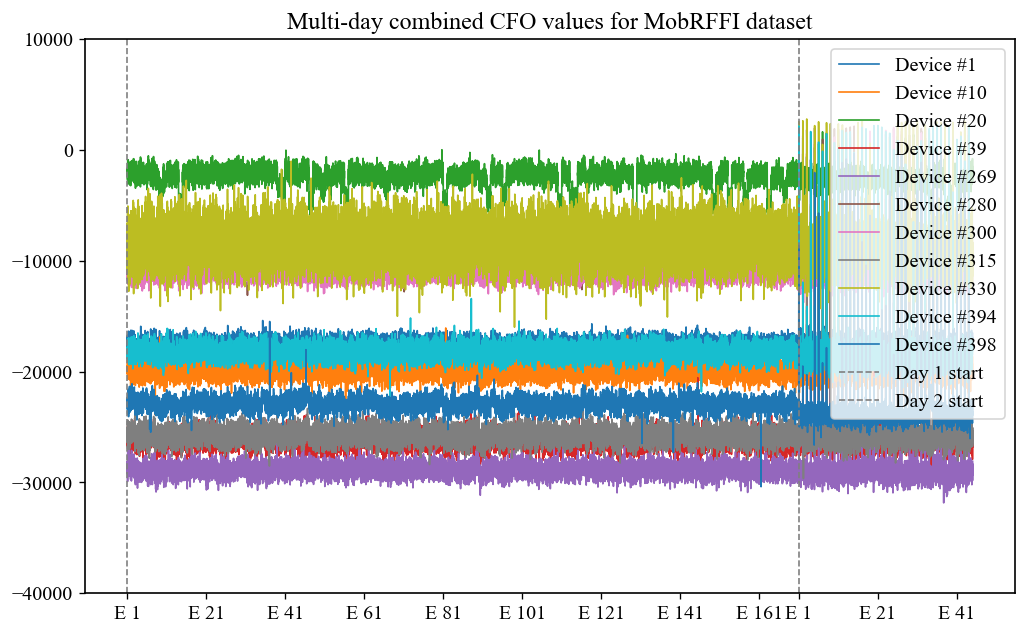

In [9]:
# 1. Let's find a common set of devices across both days
_, dataset_epoch_paths_v2, _, _, node_ids_epoch_v2, _ = dataset_api.load_dataset_info(DatasetAPI.DATASET_V2, rx_name='node1-1', allowed_epochs=[])
_, dataset_epoch_paths_v4, _, _, node_ids_epoch_v4, _= dataset_api.load_dataset_info(DatasetAPI.DATASET_V4, rx_name='node1-1', allowed_epochs=[])

mobrffi_node_ids = utils.intersect_n(node_ids_epoch_v2, node_ids_epoch_v4)
mobrffi_epoch_paths = [dataset_epoch_paths_v2, dataset_epoch_paths_v4]

epoch_frames = 100

# 2. Let's estimate coarse, fine and combined CFO values across all epochs & days
mobrffi_cfo = np.zeros((len(mobrffi_node_ids), 0, 2))
mobrffi_day_start_idx = [0]

# Loop through all days
for i, day_epochs in enumerate(mobrffi_epoch_paths):
    print(f'Day {i+1}: ', end='')
    # Loop through all epochs in a day
    for epoch_path in day_epochs:
        all_devices_passed = True
        cfo_epoch_devices = np.zeros((len(mobrffi_node_ids), epoch_frames, 2))
        # Retrieve data for an epoch
        data, labels, _ = dataset_api.load_raw_dataset(epoch_path, shuffle=False)
        for j, device_id in enumerate(mobrffi_node_ids):
            # Filter data from a single device
            data_device, _, _ = dataset_api.filter_dataset(data, labels, None, [device_id], range(epoch_frames))
            # Obtain CFO values
            if data_device is not None: 
                cfo_epoch_devices[j, :, :] = cfo_utils.extract_data_cfo(data_device)
            else: 
                all_devices_passed = False
                break

        # Some epochs don't have signal for all devices, so in such case we skip these epochs
        if all_devices_passed:
            mobrffi_cfo = np.concatenate((mobrffi_cfo, cfo_epoch_devices), axis=1)
            print('.', end='')
        else: print('!', end='')
    print()
    mobrffi_day_start_idx.append(mobrffi_cfo.shape[1])

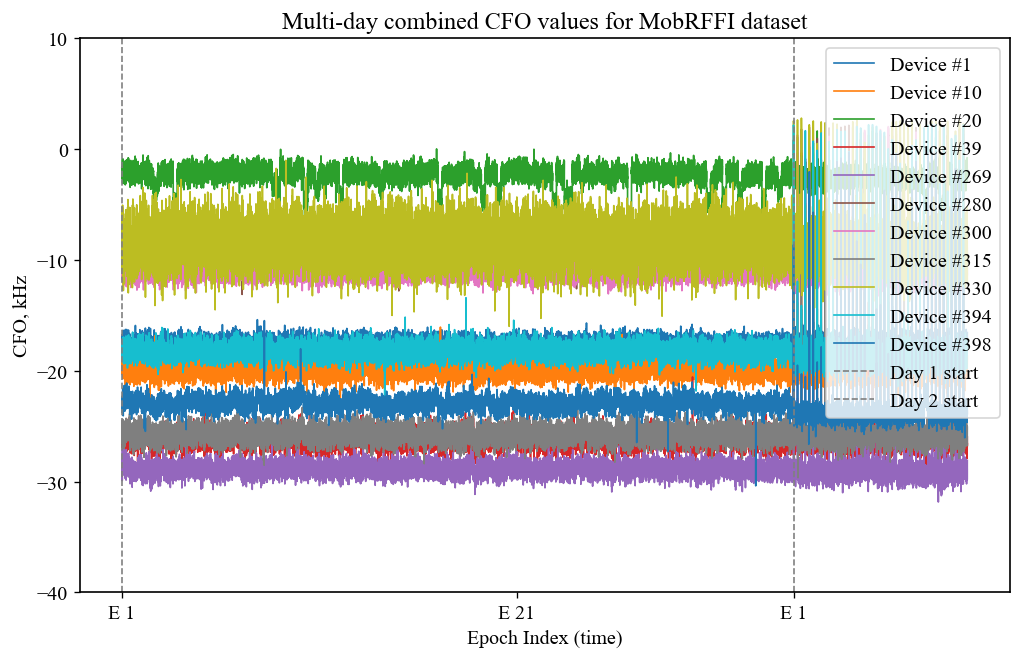

In [14]:
# 3. Plot CFO values
plot_dataset_cfo(mobrffi_cfo, mobrffi_node_ids, mobrffi_day_start_idx, epoch_frames, epoch_skip=20, figtitle='Multi-day combined CFO values for MobRFFI dataset')

### 2. CFO values in WiSig dataset

1. We evaluate CFO across all 4 days of the dataset.
2. We find a subset of emitters that are common across all of the days.
3. We estimate CFO values for each day, and then concatenate them into a single array across all epochs and days.

Day 1: .


Day 2: .
Day 3: .
Day 4: .


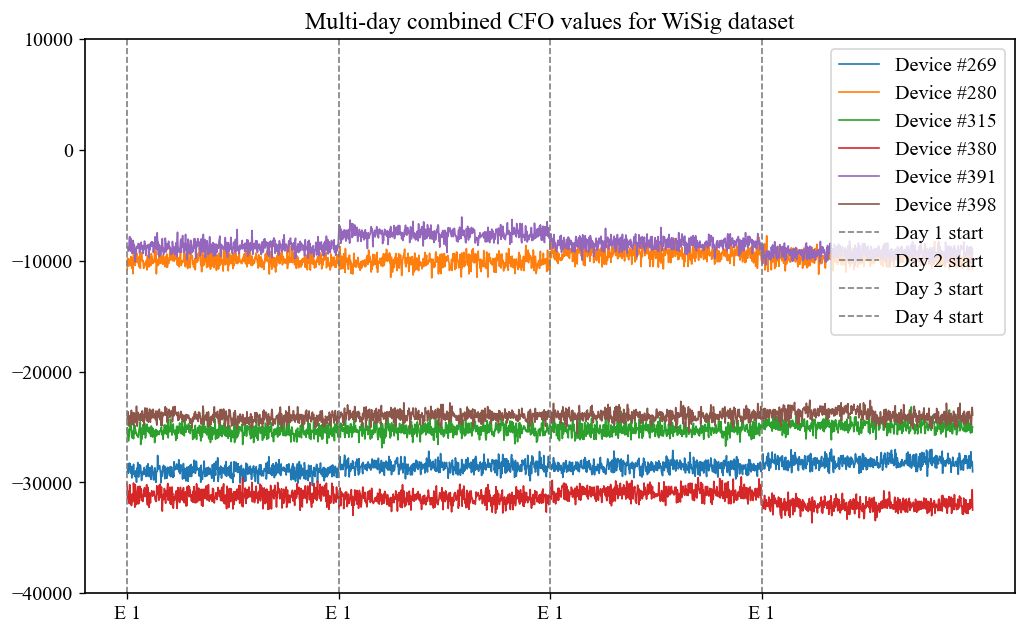

In [10]:
# 1. Let's find a common set of devices across both days
wisig_dataset_paths, _, _, wisig_node_ids, _ = dataset_api.load_dataset_info(DatasetAPI.DATASET_WISIG_NEW, rx_name='node1-1', allowed_epochs=[])
epoch_frames = 500 

# 2. Let's estimate coarse, fine and combined CFO values across all epochs & days
wisig_cfo = np.zeros((len(wisig_node_ids), 0, 2))
wisig_day_start_idx = [0]

# Loop through all days
for i, day_path in enumerate(wisig_dataset_paths):
    print(f'Day {i+1}: .')
    # Loop through all epochs in a day
    cfo_epoch_devices = np.zeros((len(wisig_node_ids), epoch_frames, 2))
    # Retrieve data for an epoch
    data, labels, _ = dataset_api.load_raw_dataset(day_path, shuffle=False)
    for j, device_id in enumerate(wisig_node_ids):
        # Filter data from a single device
        data_device, _, _ = dataset_api.filter_dataset(data, labels, None, [device_id], range(epoch_frames))
        # Obtain CFO values
        cfo_epoch_devices[j, :, :] = cfo_utils.extract_data_cfo(data_device)

    wisig_cfo = np.concatenate((wisig_cfo, cfo_epoch_devices), axis=1)
    wisig_day_start_idx.append(wisig_cfo.shape[1])

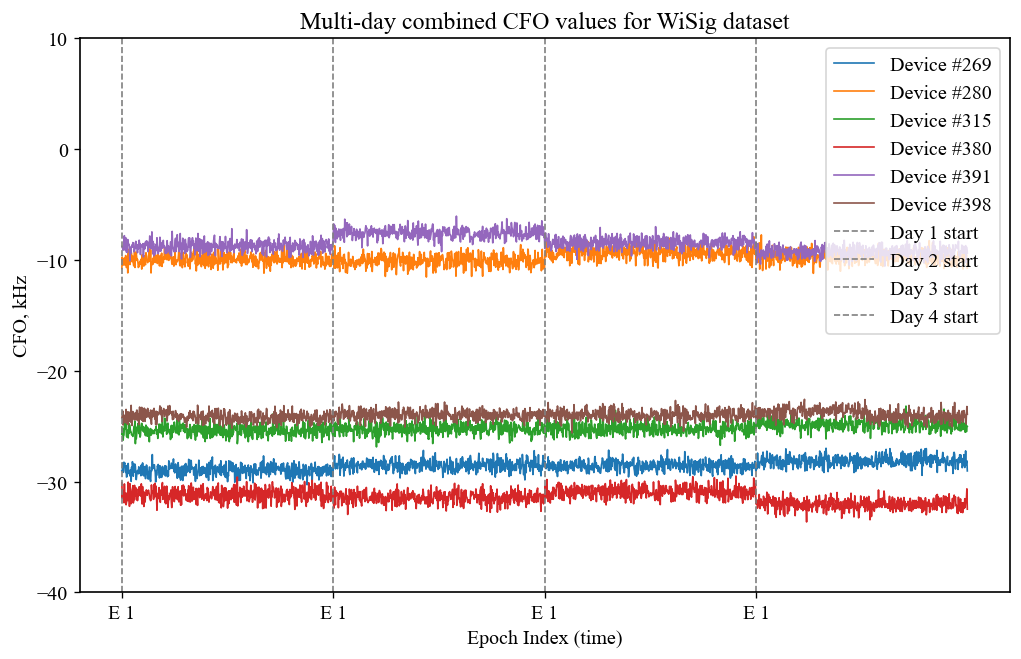

In [15]:
# 3. Plot CFO values
plot_dataset_cfo(wisig_cfo, wisig_node_ids, wisig_day_start_idx, epoch_frames, epoch_skip=1, figtitle='Multi-day combined CFO values for WiSig dataset')